---
title: General Formulation
---


<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/dnn_clipping.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



In the previous section, we showed that composing two shallow networks yields a special case of a deep network with two hidden layers. 

Now we consider the general case of a deep network with two hidden layers, each containing three hidden units, shown in figure below:

<img src="assets/Chap04/DeepTwoLayer.svg" style="filter: invert(1);" width="100%" label="fig:dnn_two_layer">

The first layer is defined by:

\begin{eqnarray}\label{eq:dnn_three_layer_in}
 h_{1} &=& \mbox{a}[\theta_{10} + \theta_{11}x] \nonumber \\
 h_{2} &=& \mbox{a}[\theta_{20} + \theta_{21}x] \nonumber \\
 h_{3} &=& \mbox{a}[\theta_{30} + \theta_{31}x],
 \end{eqnarray}

the second layer by:

\begin{eqnarray}\label{eq:dnn_three_layer_middle2}
 h'_{1} &=& \mbox{a}[\psi_{10} + \psi_{11}h_{1}+ \psi_{12}h_{2}+ \psi_{13}h_{3}] \nonumber \\
 h'_{2} &=& \mbox{a}[\psi_{20} + \psi_{21}h_{1}+ \psi_{22}h_{2}+ \psi_{23}h_{3}] \nonumber \\
 h'_{3} &=& \mbox{a}[\psi_{30} + \psi_{31}h_{1}+ \psi_{32}h_{2}+ \psi_{33}h_{3}],
 \end{eqnarray}

and the output by:

\begin{eqnarray}
\label{eq:dnn_three_layer_out}
 y' = \phi'_{0}+\phi'_{1}h'_{1}+\phi'_{2}h'_{2}+\phi'_{3}h'_{3}.
\tag{4.9}
\end{eqnarray}

Abc \ref{eq:dnn_three_layer_out} and \ref{fig:dnn_two_layer}

Considering these equations leads to another way to think about how the network constructs an increasingly complicated function (figure 4.5):


<img src="assets/Chap04/DeepBuildUp.svg" style="filter: invert(1);" width="100%">

Computation for the deep network in figure 4.4. a–c) The inputs
to the second hidden layer (i.e., the pre-activations) are three piecewise linear
functions where the “joints” between the linear regions are at the same places
(see figure 3.6). d–f) Each piecewise linear function is clipped to zero by the
ReLU activation function. g–i) These clipped functions are then weighted with
parameters $ϕ′_1$, $ϕ′_2$, and $ϕ′_3$, respectively. j) Finally, the clipped and weighted
functions are summed and an offset $ϕ′_0$ that controls the overall height is added.
(Interactive figure)

1. The three hidden units $h_1$, $h_2$, and $h_3$ in the first layer are computed as usual by forming linear functions of the input and passing these through ReLU activation functions.

2. The pre-activations at the second layer are computed by taking three new linear functions of these hidden units (arguments of the activation functions in equation 4.8). At this point, we effectively have a shallow network with three outputs;
we have computed three piecewise linear functions with the “joints” between linear
regions in the same places (see figure 3.6).

3. At the second hidden layer, another ReLU function a[•] is applied to each function
(equation 4.8), which clips them and adds new “joints” to each.

4. The final output is a linear combination of these hidden units (equation 4.9).

    In conclusion, we can either think of each layer as “folding” the input space or as creating new functions, which are clipped (creating new regions) and then recombined.

    The former view emphasizes the dependencies in the output function but not how clipping creates new joints, and the latter has the opposite emphasis. 

    Ultimately, both descriptions provide only partial insight into how deep neural networks operate. Regardless, it’s important not to lose sight of the fact that this is still merely an equation relating
input x to output y′. Indeed, we can combine equations 4.7–4.9 to get one expression:


\begin{eqnarray}\label{eq:dnn_expanded}
 y' &=& \phi'_{0}+\phi'_{1}\mbox{a}\left[\psi_{10} + \psi_{11}\mbox{a}[\theta_{10} + \theta_{11}x] + \psi_{12}\mbox{a}[\theta_{20} + \theta_{21}x]+ \psi_{13}\mbox{a}[\theta_{30} + \theta_{31}x]\right]\nonumber \\
 &&\hspace{0.55cm}+\phi'_{2}\mbox{a}[\psi_{20} + \psi_{21}\mbox{a}[\theta_{10} + \theta_{11}x] + \psi_{22}\mbox{a}[\theta_{20} + \theta_{21}x]+ \psi_{23}\mbox{a}[\theta_{30} + \theta_{31}x]] \nonumber\\
 &&\hspace{0.55cm}+\phi'_{3}\mbox{a}[\psi_{30} + \psi_{31}\mbox{a}[\theta_{10} + \theta_{11}x] + \psi_{32}\mbox{a}[\theta_{20} + \theta_{21}x]+ \psi_{33}\mbox{a}[\theta_{30} + \theta_{31}x]],\nonumber \\
 \end{eqnarray}

although this is admittedly rather diﬀicult to understand.


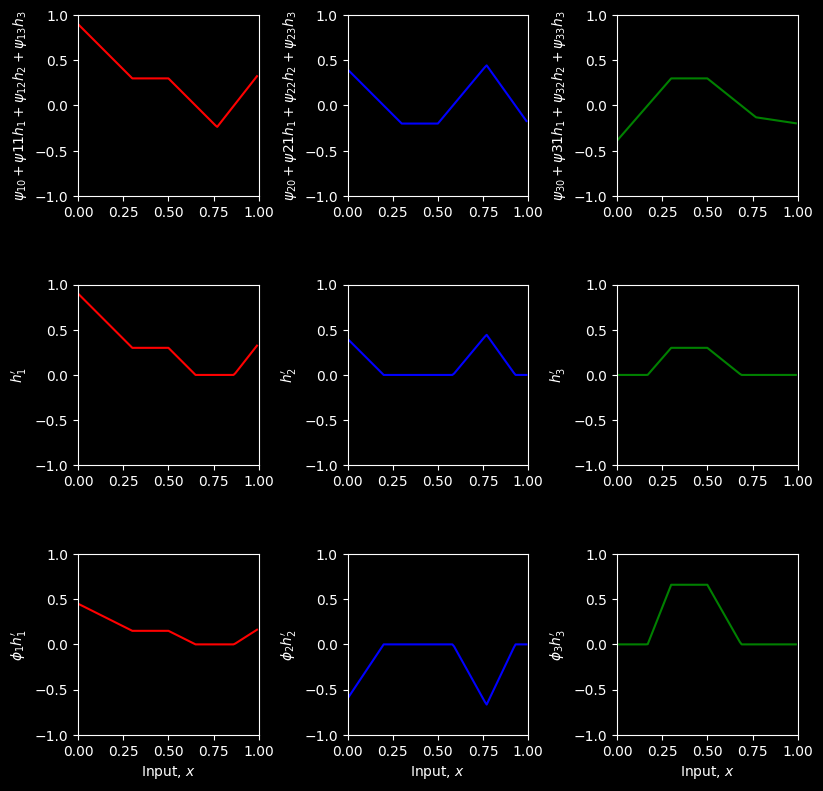

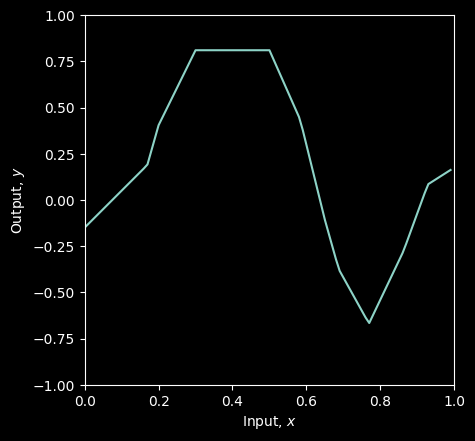

In [8]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
plt.style.use('dark_background')


theta = np.zeros([4,2])
theta[1,0] =  0.3 ;  theta[1,1] = -1.0
theta[2,0] = -1.0  ; theta[2,1] =  2.0
theta[3,0] = -0.5  ; theta[3,1] =  0.65


psi = np.zeros([4,4])
psi[1,0] =  0.3;  psi[1,1] =  2.0; psi[1,2] = -1.0; psi[1,3]=  7.0
psi[2,0] = -0.2;  psi[2,1] =  2.0; psi[2,2] =  1.2; psi[2,3]= -8.0
psi[3,0] =  0.3;  psi[3,1] = -2.3; psi[3,2] = -0.8; psi[3,3]=  2.0


phi = np.zeros([4,1])
phi[0] = 0.0; phi[1] = 0.5; phi[2] = -1.5; phi [3] = 2.2
     

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation
     

# Define a deep neural network with, one input, one output, two hidden layers and three hidden units (eqns 4.7-4.9)
# To make this easier, we store the parameters in ndarrays, so phi_0 = phi[0] and psi_3,3 = psi[3,3] etc.
def shallow_1_1_3_3(x, activation_fn, phi, psi, theta):

  # Preactivations at layer 1
  layer1_pre_1 = theta[1][0] + theta[1][1]*x ;
  layer1_pre_2 = theta[2][0] + theta[2][1]*x ;
  layer1_pre_3 = theta[3][0] + theta[3][1]*x ;

  # Activation functions
  h1 = activation_fn(layer1_pre_1)
  h2 = activation_fn(layer1_pre_2)
  h3 = activation_fn(layer1_pre_3)

  # Preactivations at layer 2
  layer2_pre_1 = psi[1][0] + psi[1][1]*h1 + psi[1][2]*h2 + psi[1][3]*h3 ;
  layer2_pre_2 = psi[2][0] + psi[2][1]*h1 + psi[2][2]*h2 + psi[2][3]*h3 ;
  layer2_pre_3 = psi[3][0] + psi[3][1]*h1 + psi[3][2]*h2 + psi[3][3]*h3 ;

  # Activation functions 
  h1_prime = activation_fn(layer2_pre_1)
  h2_prime = activation_fn(layer2_pre_2)
  h3_prime = activation_fn(layer2_pre_3)

  # Weighted outputs by phi 
  phi1_h1_prime = phi[1]*h1_prime ;
  phi2_h2_prime = phi[2]*h2_prime ;
  phi3_h3_prime = phi[3]*h3_prime ;

  # Combine weighted activation and add y offset (summing terms of equation 4.9)
  y = phi[0] + phi1_h1_prime + phi2_h2_prime + phi3_h3_prime ;

  # Return everything we have calculated
  return y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime


# # Plot two layer neural network as in figure 4.5
def plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime):

    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)                  
    ax[0,0].plot(x,layer2_pre_1,'r-'); ax[0,0].set_ylabel(r'$\psi_{10} + \psi{11}h_1 + \psi_{12}h_2 + \psi_{13}h_3$')
    ax[0,1].plot(x,layer2_pre_2,'b-'); ax[0,1].set_ylabel(r'$\psi_{20} + \psi{21}h_1 + \psi_{22}h_2 + \psi_{23}h_3$')
    ax[0,2].plot(x,layer2_pre_3,'g-'); ax[0,2].set_ylabel(r'$\psi_{30} + \psi{31}h_1 + \psi_{32}h_2 + \psi_{33}h_3$')
    ax[1,0].plot(x,h1_prime,'r-'); ax[1,0].set_ylabel(r"$h^{\prime}_1$")
    ax[1,1].plot(x,h2_prime,'b-'); ax[1,1].set_ylabel(r"$h^{\prime}_2$")
    ax[1,2].plot(x,h3_prime,'g-'); ax[1,2].set_ylabel(r"$h^{\prime}_3$")
    ax[2,0].plot(x,phi1_h1_prime,'r-'); ax[2,0].set_ylabel(r"$\phi_1 h^{\prime}_1$")
    ax[2,1].plot(x,phi2_h2_prime,'b-'); ax[2,1].set_ylabel(r"$\phi_2 h^{\prime}_2$")
    ax[2,2].plot(x,phi3_h3_prime,'g-'); ax[2,2].set_ylabel(r"$\phi_3 h^{\prime}_3$")

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel(r'Input, $x$');
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x,y)
    ax.set_xlabel(r'Input, $x$'); ax.set_ylabel(r'Output, $y$')
    ax.set_xlim([0,1]);ax.set_ylim([-1,1])
    ax.set_aspect(0.5)
    plt.show()

# Define parameters (note first dimension of theta and psi is padded to make indices match
# notation in book)

# Define a range of input values
x = np.arange(0,1,0.01)

# Run the neural network
y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime \
    = shallow_1_1_3_3(x, ReLU, phi, psi, theta)

# And then plot it
plot_neural_two_layers(x, y, layer2_pre_1, layer2_pre_2, layer2_pre_3, h1_prime, h2_prime, h3_prime, phi1_h1_prime, phi2_h2_prime, phi3_h3_prime)


<!-- ### Hyperparameters -->
<br/><br/>

We can extend the deep network construction to more than two hidden layers; modern networks might have more than a hundred layers with thousands of hidden units at each layer. 

The number of hidden units in each layer is referred to as the <u>width</u> of the network, and the number of hidden layers as the <u>depth</u>. 

The total number of hidden units is a measure of the <u>network’s capacity</u>.

We denote the number of layers as $K$ and the number of hidden units in each layer
as $D_1, D_2, \ldots, D_K$. These are examples of hyperparameters. They are quantities chosen
before we learn the model parameters (i.e., the slope and intercept terms). For fixed
hyperparameters (e.g., $K = 2$ layers with $D_k = 3$ hidden units in each), the model
describes a family of functions, and the parameters determine the particular function.
Hence, when we also consider the hyperparameters, we can think of neural networks as
representing a family of families of functions relating input to output.



<img src="assets/Chap04/DeepKLayer.svg" style="filter: invert(1);" width="100%">

Matrix notation for network with Di = 3-dimensional input x, Do = 2-
dimensional output y, and K = 3 hidden layers h1, h2, and h3 of dimensions
$D_1$ = 4, $D_2$ = 2, and $D_3$ = 3 respectively. The weights are stored in matrices $\Omega_k$
that multiply the activations from the preceding layer to create the pre-activations
at the subsequent layer. For example, the weight matrix $\Omega_1$ that computes the
pre-activations at $h_2$ from the activations at $h_1$ has dimension 2×4. It is applied
to the four hidden units in layer one and creates the inputs to the two hidden
units at layer two. The biases are stored in vectors $\beta_k$ and have the dimension
of the layer into which they feed. For example, the bias vector $\beta_2$ is length three
because layer $h_3$ contains three hidden units.

<!-- ### Matrix Notation  -->
<br/><br/>

We have seen that a deep neural network consists of linear transformations alternating with activation functions. We could equivalently describe equations 4.7–4.9 in matrix
notation as:

\begin{eqnarray}
  \begin{bmatrix}
  h_{1} \\ h_{2} \\ h_{3}
  \end{bmatrix}
  = \mbox{\bf a}\left[\begin{bmatrix}\theta_{10}\\ \theta_{20}\\ \theta_{30} \end{bmatrix}+\begin{bmatrix}\theta_{11}\\\theta_{21}\\\theta_{31}\end{bmatrix}x\right],
 \end{eqnarray}

\begin{eqnarray}
  \begin{bmatrix}
  h'_{1} \\ h'_{2} \\h'_{3} 
  \end{bmatrix}
  =\mbox{\bf a}\left[\begin{bmatrix}\psi_{10} \\ \psi_{20}\\ \psi_{30}\end{bmatrix} + \begin{bmatrix}\psi_{11} &\psi_{12} & \psi_{13} \\\psi_{21} &\psi_{22} & \psi_{23} \\\psi_{31} &\psi_{32} & \psi_{33} \end{bmatrix} \begin{bmatrix}
  h_{1} \\ h_{2} \\ h_{3}
  \end{bmatrix} \right],
  \end{eqnarray}

\begin{eqnarray}
  y' = \phi'_{0} + \begin{bmatrix} \phi'_{1} & \phi'_{2} & \phi'_{3} \end{bmatrix}\begin{bmatrix}h'_{1} \\ h'_{2} \\h'_{3} \end{bmatrix},
 \end{eqnarray}

or even more compactly in matrix notation as:

\begin{eqnarray}
  \mathbf{h} &=& \mbox{\bf a}\left[\boldsymbol\theta_{0}+\boldsymbol\theta x\right] \nonumber\\
  \mathbf{h}' &=& \mbox{\bf a}\left[\boldsymbol\psi_{0}+\boldsymbol\Psi \mathbf{h}\right] \nonumber \\
  y' &=& \phi'_{0} + \boldsymbol\phi' \mathbf{h}',
 \end{eqnarray}

where, in each case, the function a[•] applies the activation function separately to every element of its vector input.

<br/><br/>

This notation becomes cumbersome for networks with many layers. Hence, from now
on, we will describe the vector of hidden units at layer k as hk , the vector of biases
(intercepts) that contribute to hidden layer k+ 1 as βk , and the weights (slopes) that
are applied to the kth layer and contribute to the (k+1)th layer as Ωk . A general deep
network y= f[x,ϕ] with K layers can now be written as:

\begin{eqnarray}\label{eq:dnn_la1}
  \mathbf{h}_{1} &=& \mathbf{a}[\boldsymbol\beta_{0} +\boldsymbol\Omega_{0}\mathbf{x}]\nonumber \\
  \mathbf{h}_{2} &=& \mathbf{a}[\boldsymbol\beta_{1} +\boldsymbol\Omega_{1}\mathbf{h}_{1}]\nonumber \\
  \mathbf{h}_{3} &=& \mathbf{a}[\boldsymbol\beta_{2} +\boldsymbol\Omega_{2}\mathbf{h}_{2}]\nonumber \\
  &\vdots&\nonumber\\
  \mathbf{h}_{K} &=& \mathbf{a}[\boldsymbol\beta_{K-1} +\boldsymbol\Omega_{K-1}\mathbf{h}_{K-1}] \nonumber\\
  \mathbf{y} &=& \boldsymbol\beta_{K} +\boldsymbol\Omega_{K}\mathbf{h}_{K}.
 \end{eqnarray}

The parameters ϕof this model comprise all of these weight matrices and bias vectors
$\phi = \{\beta_k ,\Omega_k \}_{k=0}^{K}$
.
If the kth layer has $D_k$ hidden units, then the bias vector $\beta_k−1$ will be of size $D_k$.
The last bias vector $\beta_K$ has the size $D_o$ of the output. The first weight matrix $\Omega_0$ has size $D_1 \times D_i$ where $D_i$ is the size of the input. The last weight matrix $\Omega_K$ is $D_o \times D_K$,
and the remaining matrices $\Omega_k$ are $D_{k+1} \times D_k$ (figure 4.6).
We can equivalently write the network as a single function: 


$$
\begin{aligned}
  \mathbf{y} = \boldsymbol\beta_{K} + \boldsymbol\Omega_{K}\mathbf{a}\left[\boldsymbol\beta_{K-1} + \boldsymbol\Omega_{K-1}\mathbf{a}\left[\ldots
  \boldsymbol\beta_{2} + \boldsymbol\Omega_{2}\mathbf{a}\left[\boldsymbol\beta_{1} + \boldsymbol\Omega_{1}\mathbf{a}\left[\boldsymbol\beta_{0} + \boldsymbol\Omega_{0}\mathbf{x}\right]\right]\ldots\right]\right].
\end{aligned}
$$ {#eq-dnn-la2}

As shown in @eq-dnn-la2...
